In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="vgg16"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.2412074443425451,train_accu=0.9186571428571428
Epoch=0,valid_loss=0.3129337548851967,valid_accu=0.8949
0
Epoch=1,train_loss=0.19616655340365002,train_accu=0.9317142857142857
Epoch=1,valid_loss=0.3124446439743042,valid_accu=0.8937
Epoch=2,train_loss=0.13839888938409942,train_accu=0.9536857142857142
Epoch=2,valid_loss=0.28121216577887537,valid_accu=0.9086
0
Epoch=3,train_loss=0.10070256539859943,train_accu=0.9680857142857143
Epoch=3,valid_loss=0.25450720935463905,valid_accu=0.9159
0
Epoch=4,train_loss=0.09796003362914281,train_accu=0.9676
Epoch=4,valid_loss=0.3032644484847784,valid_accu=0.9096
Epoch=5,train_loss=0.08359942503848246,train_accu=0.9736
Epoch=5,valid_loss=0.28035322158932685,valid_accu=0.9125
Epoch=6,train_loss=0.06045382695767496,train_accu=0.9811714285714286
Epoch=6,valid_loss=0.28560563764385877,valid_accu=0.9172
0
Epoch=7,train_loss=0.04385941733196378,train_accu=0.9858571428571429
Epoch=7,valid_loss=0.24063051609098912,valid_accu=0.9263
0
Epoch=8,tr

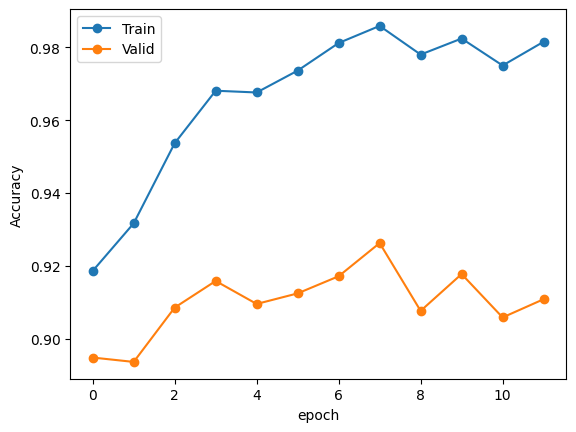

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_10.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.044566189444650496, 0.9862571428571428)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.24288049729168415, 0.926)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.986525
automobile    0.988201
bird          0.988719
cat           0.962432
deer          0.991448
dog           0.972540
frog          0.992338
horse         0.991150
ship          0.994941
truck         0.994007
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(5).index.map(trainset.dataset.classess)]
targetF

[3, 5, 0, 1, 2]

In [17]:
targetF=[0,1,8,9]

In [18]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                     

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t==0):
                            indexT.append(idx.cpu().numpy().item()) 
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                    

            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14025, 24463)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4006, 6987)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                if(t!=0):
                    flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                    flat_data.append(d.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.0004275907670997311,train_accu=0.9999047981721249
Epoch=0,valid_loss=0.022469886377107548,valid_accu=0.994115687798379
0
Epoch=1,train_loss=6.900540537572929e-06,train_accu=1.0
Epoch=1,valid_loss=0.02390539524175958,valid_accu=0.9950038858665482
0
Epoch=2,train_loss=1.500209198302833e-06,train_accu=1.0
Epoch=2,valid_loss=0.023848856699727944,valid_accu=0.9951149106250694
0
Epoch=3,train_loss=3.954561372022024e-07,train_accu=1.0
Epoch=3,valid_loss=0.025292819965570923,valid_accu=0.9945597868324636
Epoch=4,train_loss=1.339993347886112e-07,train_accu=1.0
Epoch=4,valid_loss=0.025840432188381366,valid_accu=0.9947818363495059
Epoch=5,train_loss=6.94274723651946e-07,train_accu=1.0
Epoch=5,valid_loss=0.04499241921448528,valid_accu=0.9934495392472521
Epoch=6,train_loss=1.2430966020606437e-07,train_accu=1.0
Epoch=6,valid_loss=0.04494017458128754,valid_accu=0.9942267125569002
4 Early stopping!


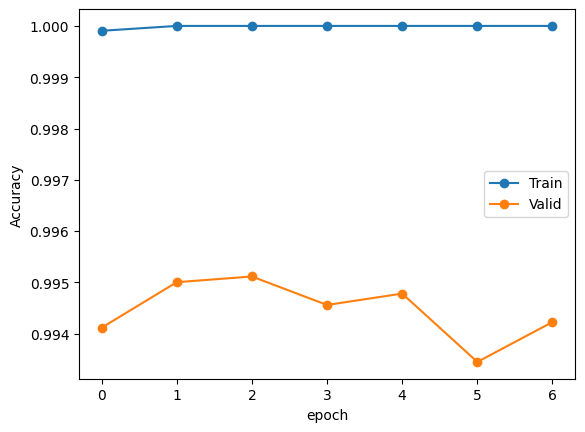

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.055532761082357315,train_accu=0.9816866287863304
Epoch=0,valid_loss=0.3177823868910864,valid_accu=0.9102619149849721
0
Epoch=1,train_loss=0.08033513785780179,train_accu=0.9731022360299227
Epoch=1,valid_loss=0.37569163033971464,valid_accu=0.9036782596250179
Epoch=2,train_loss=0.040443977415407874,train_accu=0.9874504353513469
Epoch=2,valid_loss=0.3171665998970437,valid_accu=0.9129812508945184
0
Epoch=3,train_loss=0.07768845063377354,train_accu=0.974042431427053
Epoch=3,valid_loss=0.4128488986059134,valid_accu=0.9008158007728639
Epoch=4,train_loss=0.02185552002548841,train_accu=0.9925193148837019
Epoch=4,valid_loss=0.3223524597061965,valid_accu=0.9199942750822957
0
Epoch=5,train_loss=0.03987935950737423,train_accu=0.9870416547438989
Epoch=5,valid_loss=0.32111046417024885,valid_accu=0.9128381279519107
Epoch=6,train_loss=0.04420417298618827,train_accu=0.9859379471037893
Epoch=6,valid_loss=0.36765658278916635,valid_accu=0.9063975955345642
Epoch=7,train_loss=0.0759293313

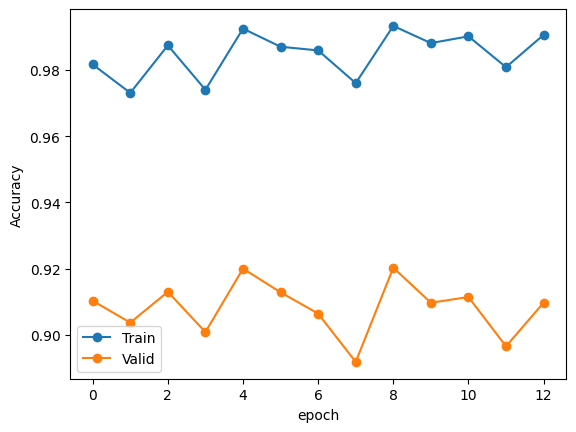

In [27]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [28]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 299, 299]           1,792
              ReLU-2         [-1, 64, 299, 299]               0
            Conv2d-3         [-1, 64, 299, 299]          36,928
              ReLU-4         [-1, 64, 299, 299]               0
         MaxPool2d-5         [-1, 64, 149, 149]               0
            Conv2d-6        [-1, 128, 149, 149]          73,856
              ReLU-7        [-1, 128, 149, 149]               0
            Conv2d-8        [-1, 128, 149, 149]         147,584
              ReLU-9        [-1, 128, 149, 149]               0
        MaxPool2d-10          [-1, 128, 74, 74]               0
           Conv2d-11          [-1, 256, 74, 74]         295,168
             ReLU-12          [-1, 256, 74, 74]               0
           Conv2d-13          [-1, 256, 74, 74]         590,080
             ReLU-14          [-1, 256,

Epoch=0,train_loss=0.019617916987976474,train_accu=0.9931550802139038
Epoch=0,valid_loss=0.1119539830994086,valid_accu=0.9660509236145781
0
Epoch=1,train_loss=0.035984797433608856,train_accu=0.9873083778966132
Epoch=1,valid_loss=0.182109803751788,valid_accu=0.9515726410384423
Epoch=2,train_loss=0.030641291260822226,train_accu=0.9893761140819964
Epoch=2,valid_loss=0.18665763228635118,valid_accu=0.9523215177234149
Epoch=3,train_loss=0.019961041229031647,train_accu=0.9935115864527629
Epoch=3,valid_loss=0.12660049541465657,valid_accu=0.9610584123814279
Epoch=4,train_loss=0.020152843052082665,train_accu=0.9931550802139038
Epoch=4,valid_loss=0.14290168036001627,valid_accu=0.9608087868197703
4 Early stopping!


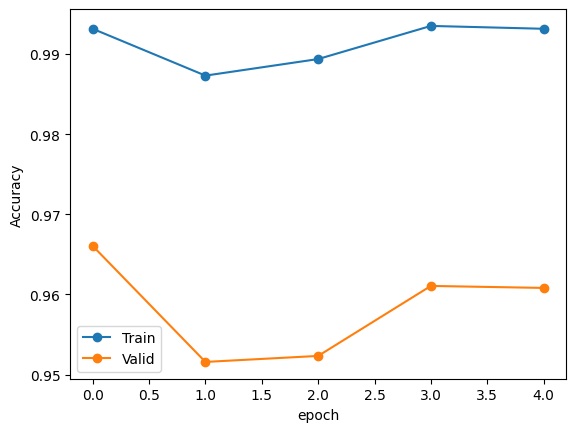

In [29]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(1.500209198302833e-06, 1.0)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.023848856699727944, 0.9951149106250694)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.019646180476740438, 0.9941953153742387)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.018085821906898218, 0.9937254901960785)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.30673119244547603, 0.9209961356805496)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.12183856395435849, 0.9615576635047429)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.019797982225725094, 0.9938857142857143, 14025)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.25991640093661844, 0.9307, 4006)

In [38]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.02565380705096759, 0.9935142857142857, 12418, 22582)

In [39]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.3195801437303424, 0.9278, 3526, 6474)

In [40]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [41]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.044566,0.986257,0.242880,0.926000
1,Model_Decision,0.000002,1.000000,0.023849,0.995115
2,Model_T,0.019646,0.994195,0.306731,0.920996
3,Model_F,0.018086,0.993725,0.121839,0.961558
4,Total_Model,0.025654,0.993514,0.319580,0.927800
5,Total_Model_without_decision,0.019798,0.993886,0.259916,0.930700


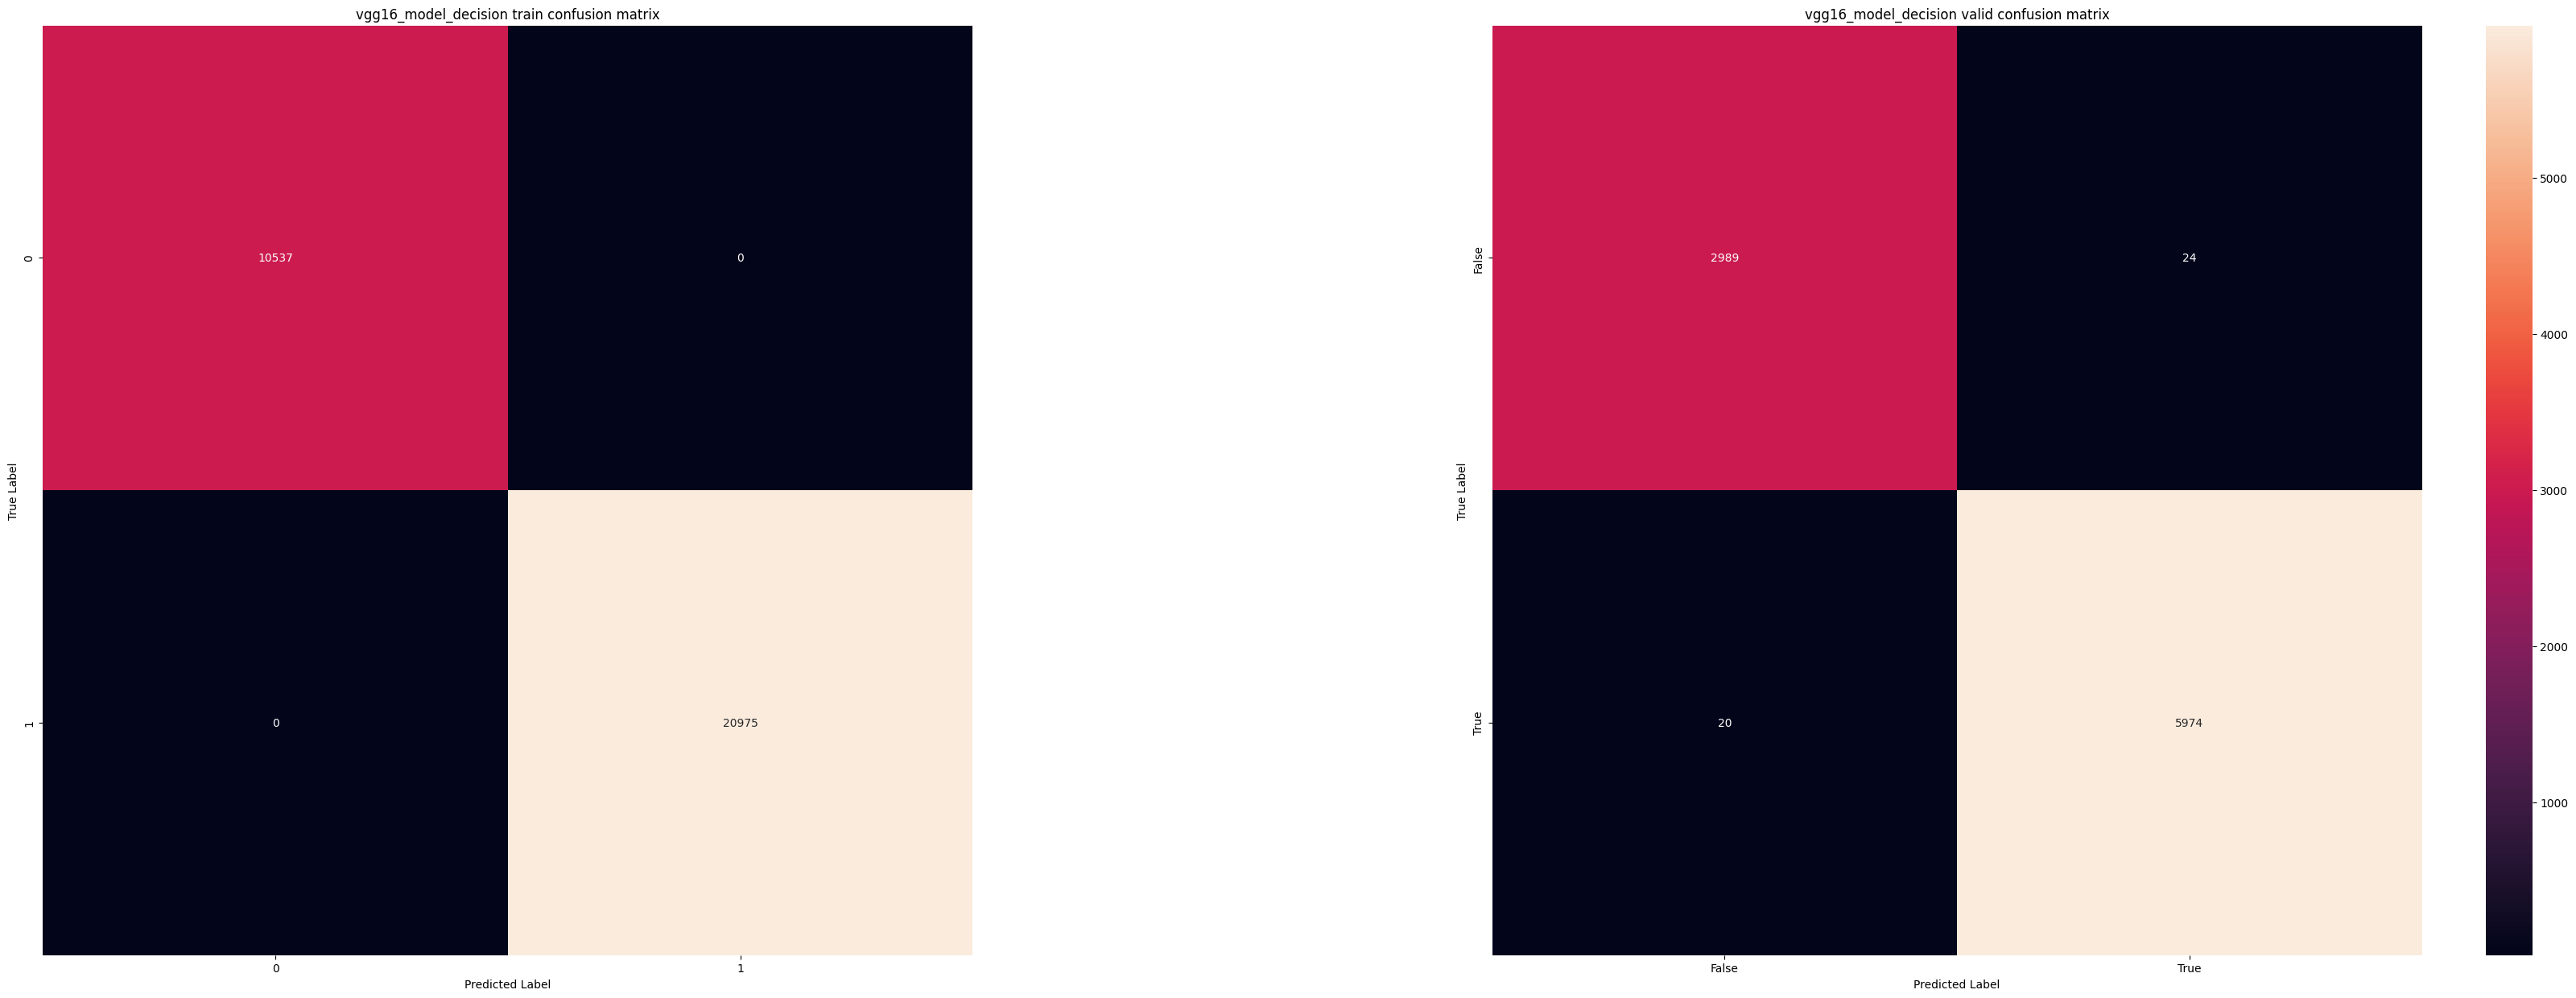

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

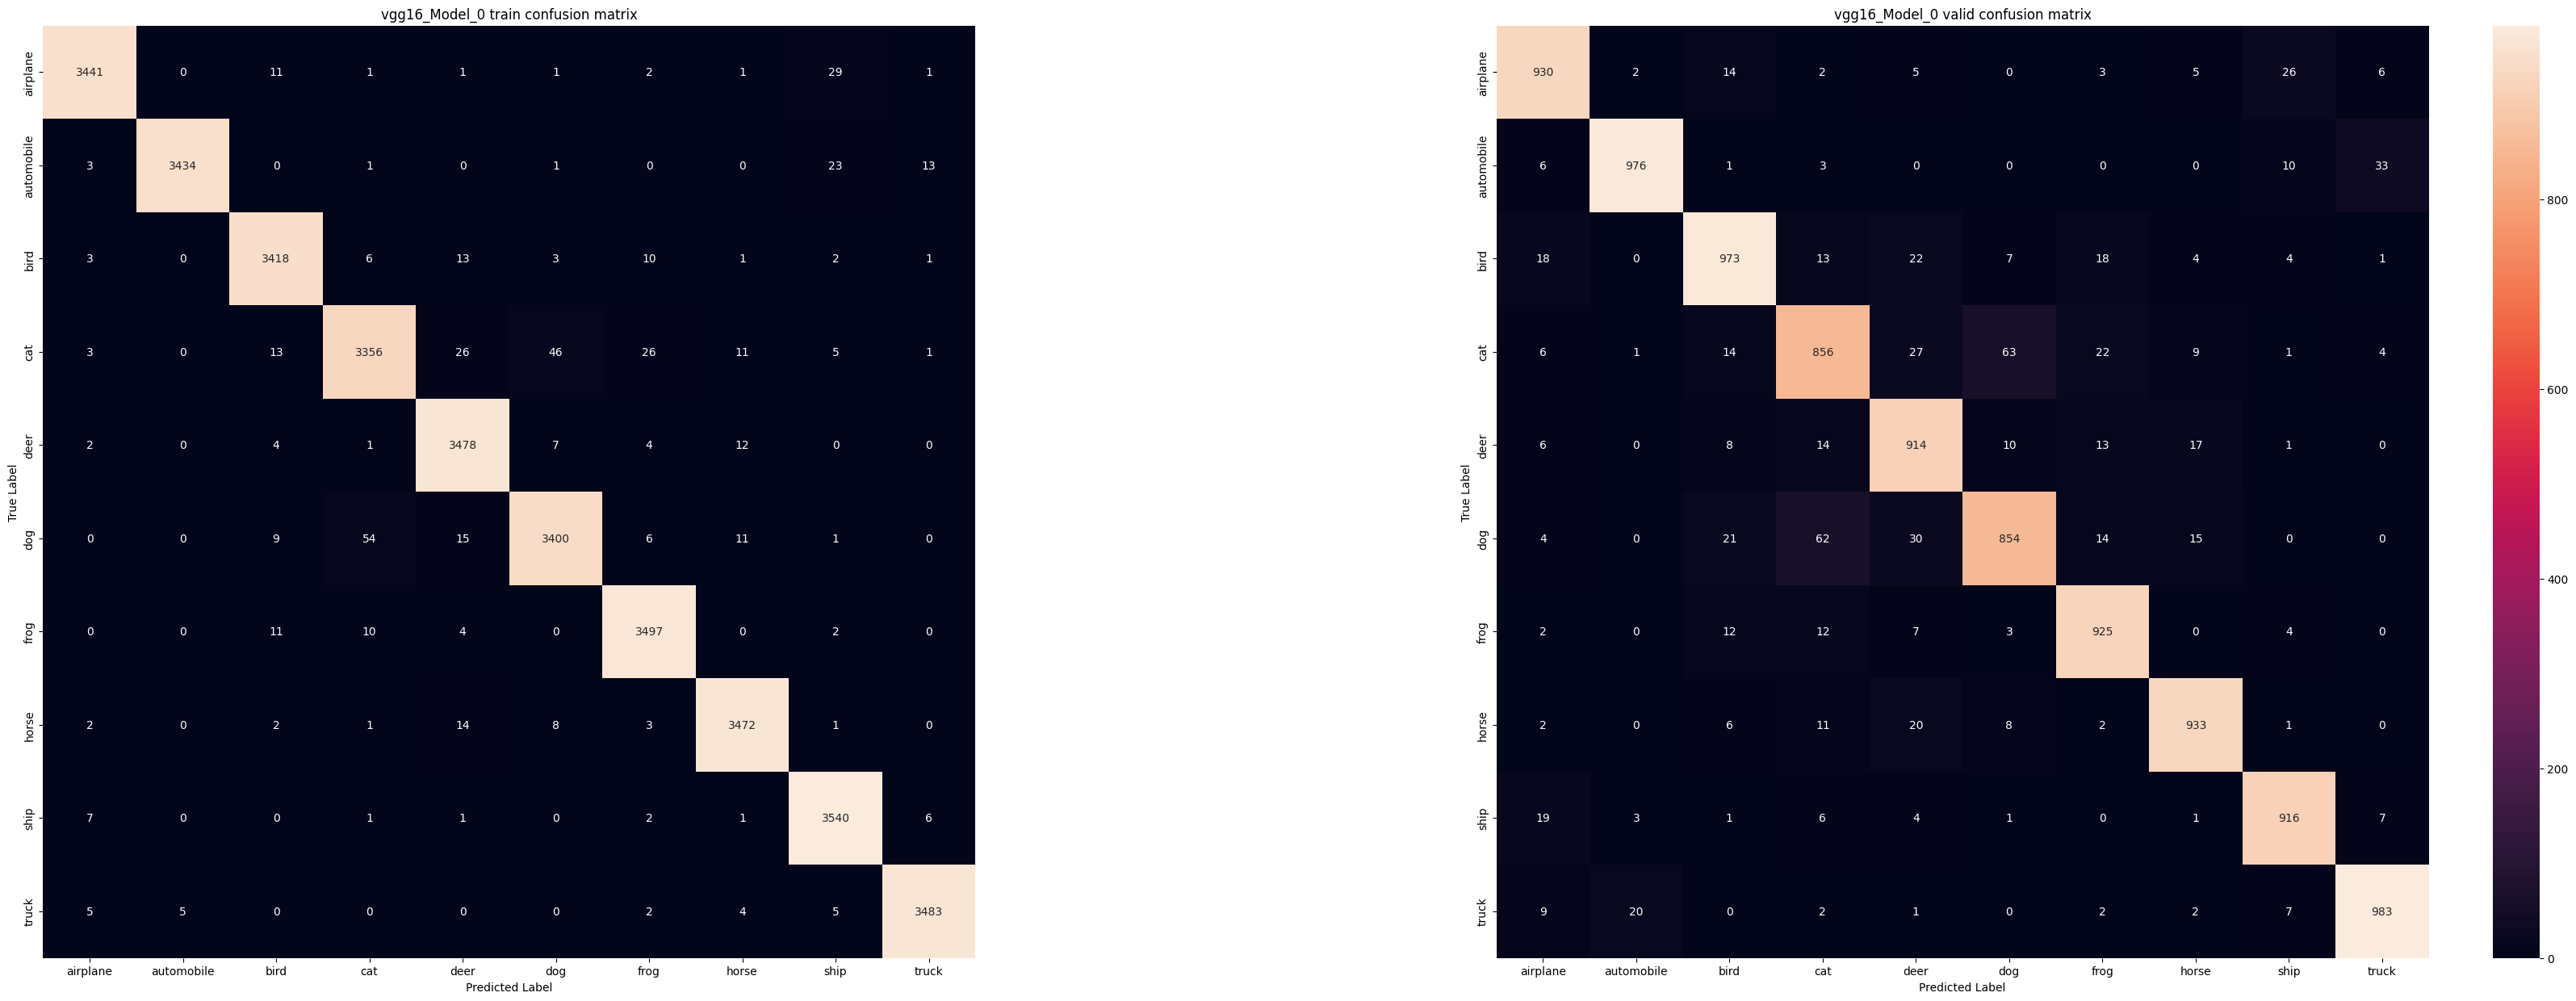

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [44]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [45]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.02863808 0.01029395 0.01028162 0.00774133 0.00741733 0.00661871
 0.00628606 0.00601413 0.00546374 0.00543021 0.00516795 0.00490074
 0.00402147 0.00344218 0.00344004]
Top 15 Positions:
[(5, 3), (6, 3), (8, 0), (4, 3), (7, 4), (8, 1), (5, 4), (6, 2), (3, 2), (7, 5), (9, 1), (4, 2), (2, 0), (5, 2), (7, 3)]


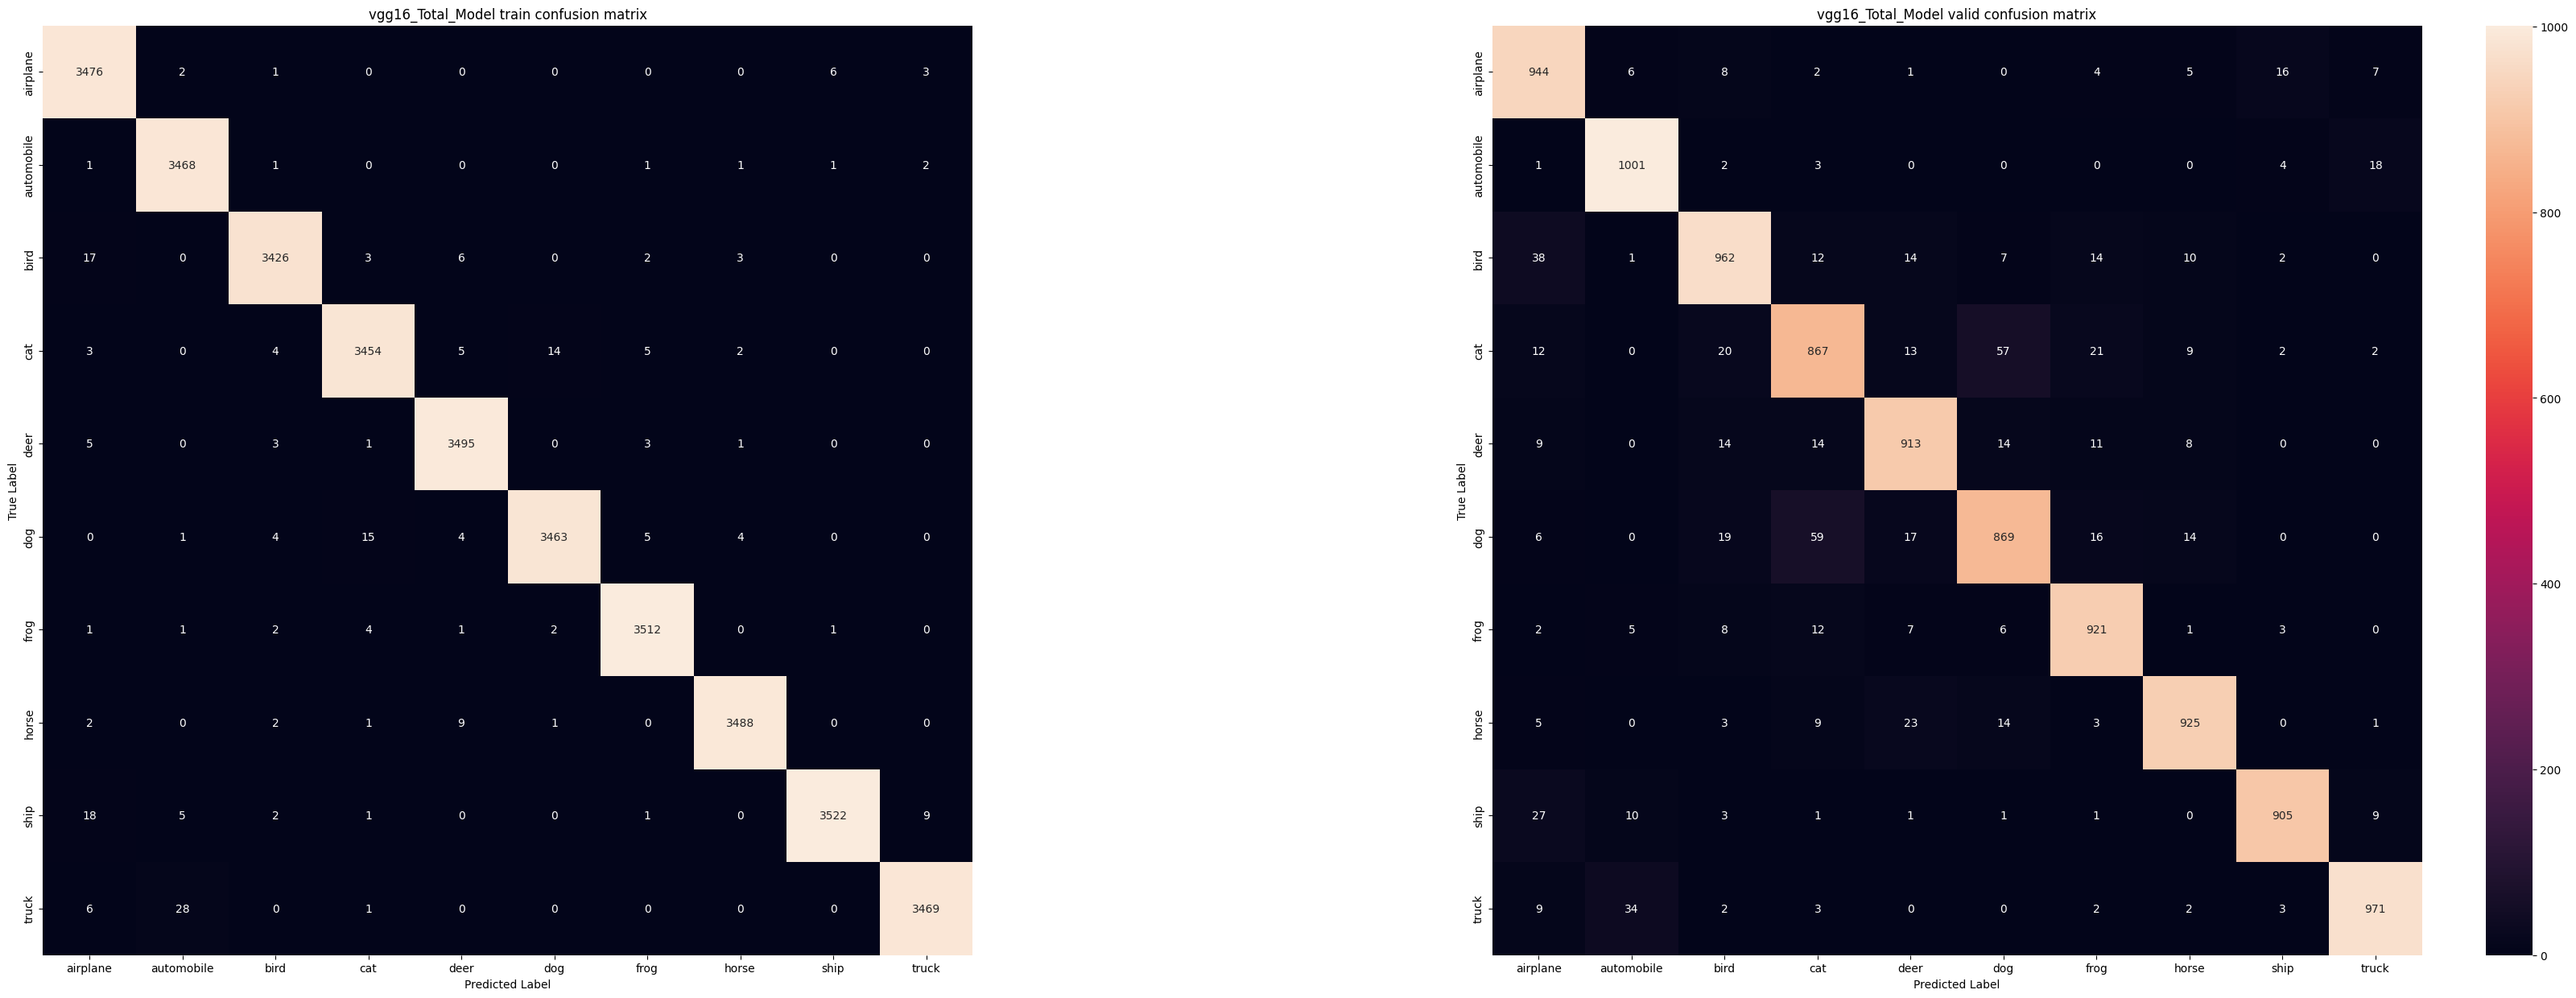

In [46]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

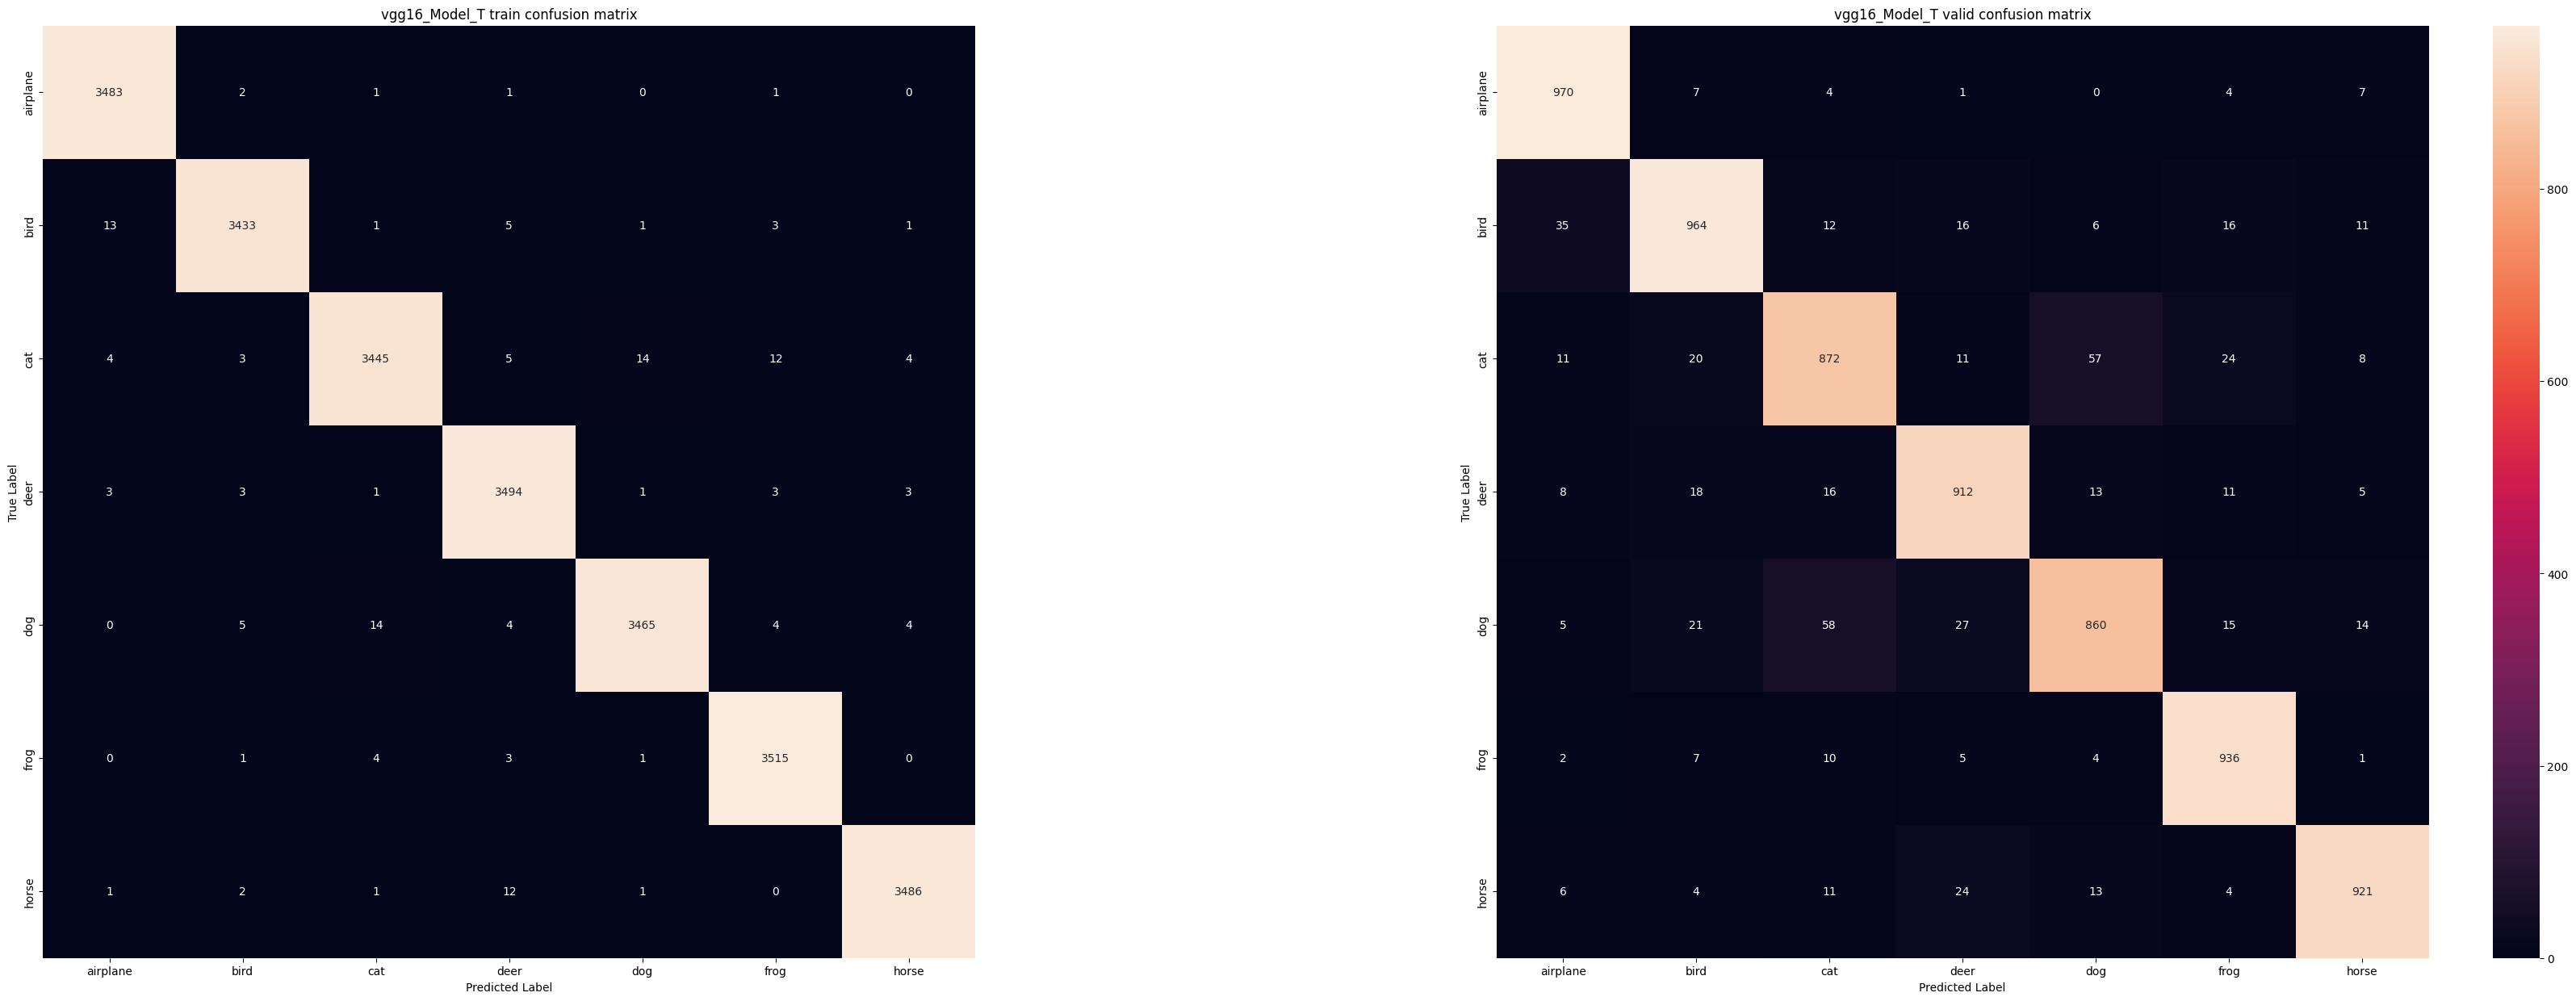

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

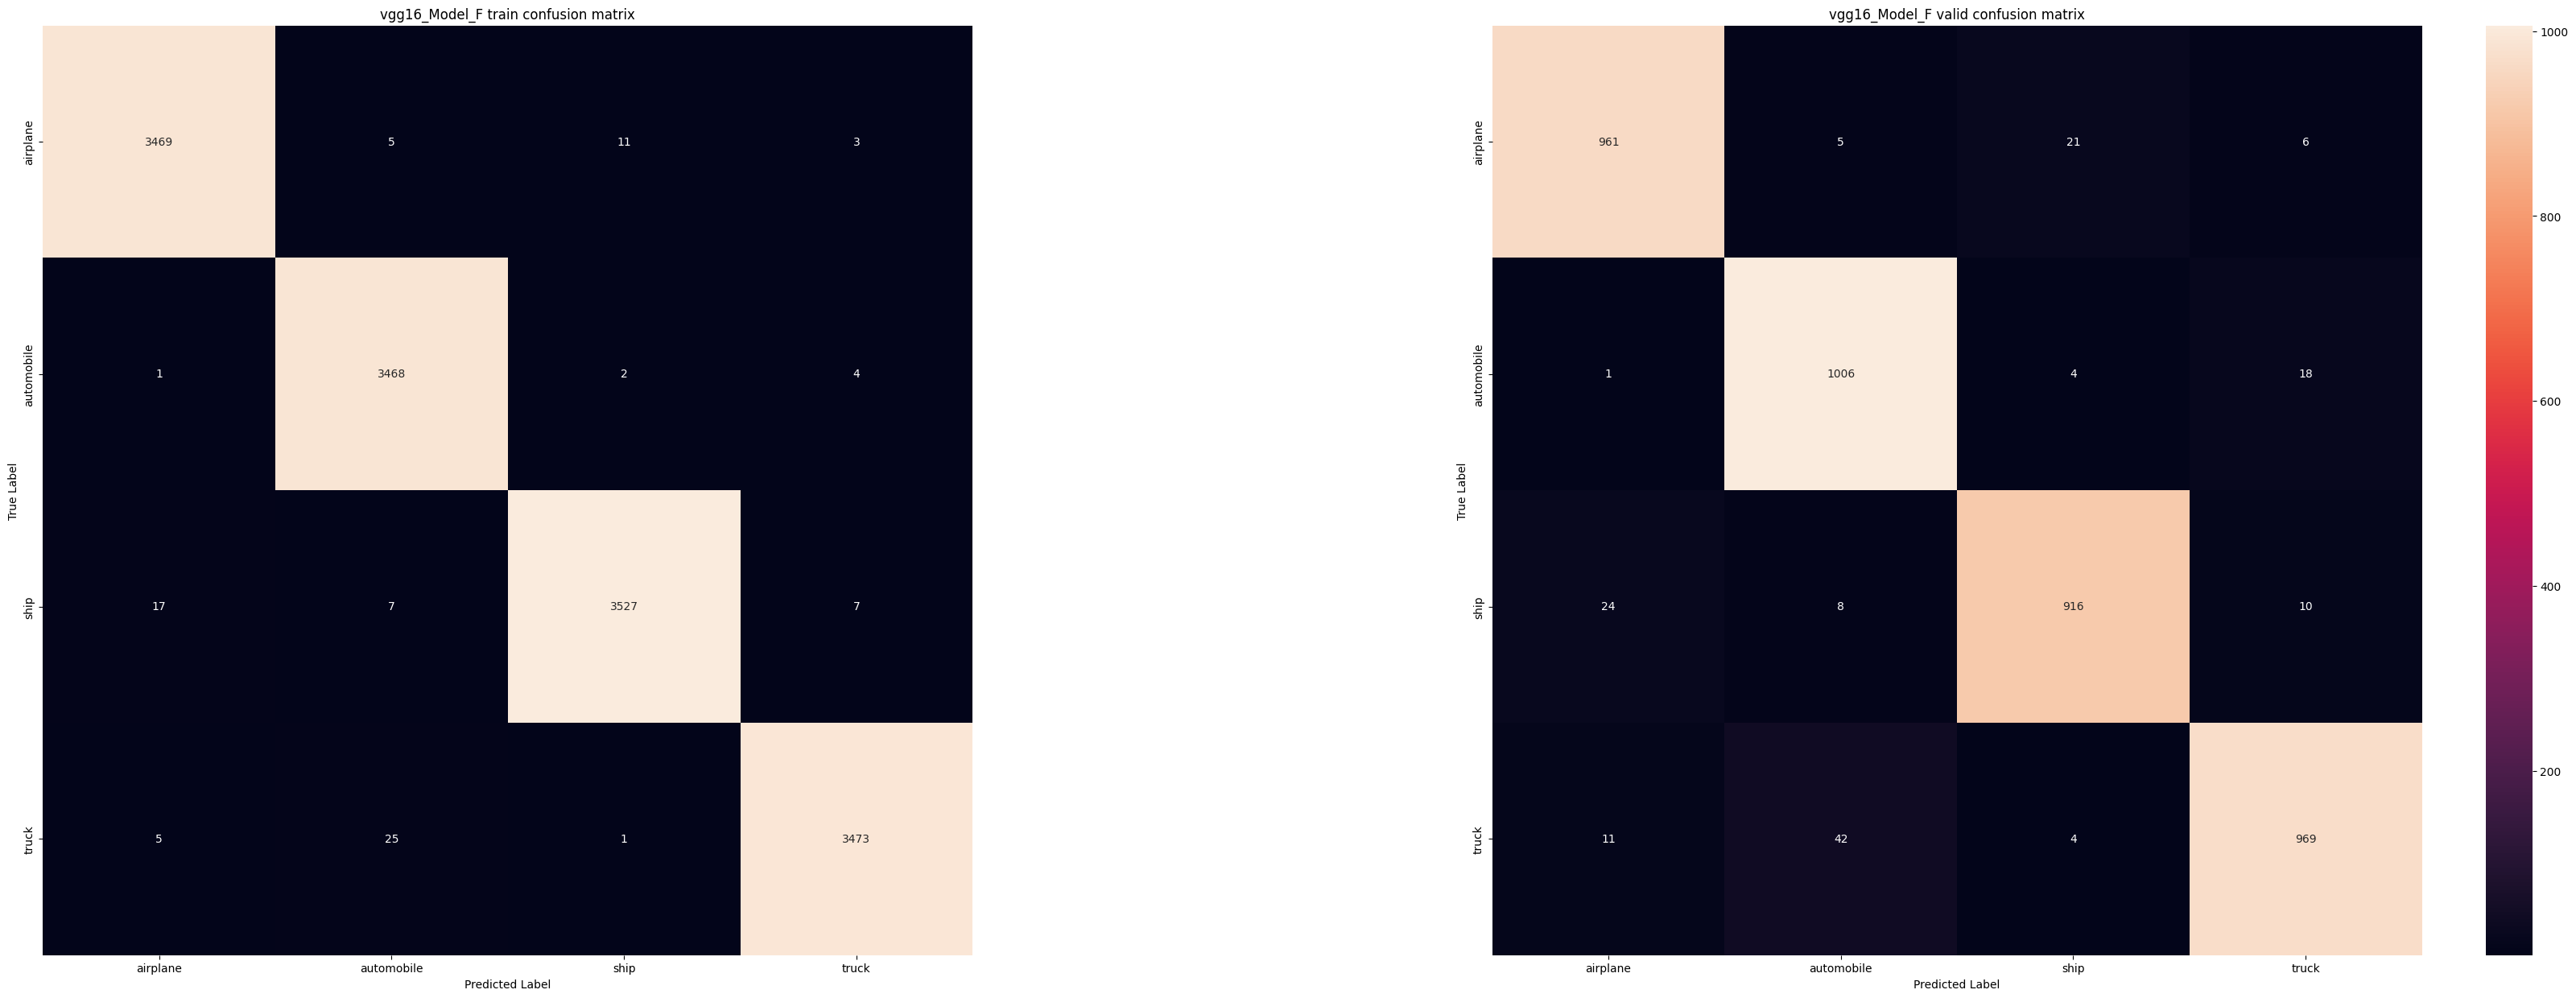

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,41241,1,1,0,1,1.000000,0.448391,0.999913,1.000000,True,False,True,False,False
1,36782,5,0,5,2,0.477533,0.977266,0.704741,1.000000,False,True,False,True,True
2,37487,6,0,6,6,0.517656,1.000000,0.999980,1.000000,False,True,True,True,True
3,4944,1,1,0,1,1.000000,0.975011,1.000000,1.000000,True,False,True,False,False
4,10540,7,0,7,7,0.999117,0.999990,0.999986,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,6440,0,0,0,0,1.000000,1.000000,0.999767,0.820294,True,True,True,True,False
34996,36871,5,0,5,5,0.898216,0.999830,0.998825,1.000000,False,True,True,True,True
34997,34133,5,0,5,5,0.422231,1.000000,1.000000,1.000000,False,True,True,True,True
34998,9233,6,1,6,6,0.865584,1.000000,1.000000,1.000000,False,True,True,True,True


In [51]:
df_results[(df_results['Target']==0)&(df_results['Match_F']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1703,11919,0,1,0,0,0.493674,0.999947,0.994822,0.989810,False,True,True,True,False
5429,25762,0,8,0,0,0.837033,0.999897,0.979172,0.999787,False,True,True,False,False
8240,7865,0,1,0,0,0.675207,1.000000,0.999685,0.938312,False,True,True,True,False
8525,36615,0,8,0,0,0.625350,0.999993,0.864552,0.930173,False,True,True,False,False
10514,21892,0,8,0,0,0.602675,0.994177,0.869740,0.783911,False,True,True,False,False
11059,48069,0,1,0,0,0.701948,1.000000,0.998473,0.999544,False,True,True,False,False
13389,17183,0,8,0,0,0.633114,0.999977,0.658028,0.999857,False,True,True,False,False
13906,34070,0,8,0,0,0.817676,0.999836,0.580836,0.999997,False,True,True,False,False
15586,42204,0,1,0,0,0.830486,0.999975,0.916474,1.000000,False,True,True,False,False
18529,40492,0,9,0,0,0.489133,0.987275,0.919074,0.976275,False,True,True,True,False


In [52]:
df_results[(df_results['Target']==0)&(df_results['Decision']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
6,42179,0,0,0,0,1.000000,1.000000,1.000000,0.999978,True,True,True,False,False
48,25431,0,0,0,0,0.999972,1.000000,0.999946,1.000000,True,True,True,False,False
55,26505,0,0,0,0,0.999968,0.884567,0.940264,0.551384,True,True,True,False,False
119,14615,0,0,0,0,1.000000,1.000000,1.000000,0.999970,True,True,True,False,False
134,8774,0,0,0,0,0.999957,1.000000,0.999982,0.998782,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34877,46749,0,0,0,0,0.820321,0.999058,0.422079,0.999999,True,True,True,False,False
34903,47336,0,0,0,0,0.994475,1.000000,0.997790,0.999935,True,True,True,False,False
34923,38238,0,0,0,0,0.888551,0.999400,0.941197,1.000000,True,True,True,False,False
34980,17947,0,0,0,0,0.999998,1.000000,0.999993,0.986401,True,True,True,False,False


In [53]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,189,0,0,2,2,0.967973,0.960338,0.408310,0.999159,True,False,False,True,False
49,12209,0,0,0,0,1.000000,0.999999,0.999994,0.675998,True,True,True,True,False
89,37189,0,0,0,0,0.999991,0.999942,0.993172,0.997641,True,True,True,True,False
122,14136,0,0,0,0,1.000000,1.000000,0.999999,0.999369,True,True,True,True,False
138,43012,0,0,0,0,1.000000,0.999994,0.997150,0.999994,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34704,5874,0,0,0,0,0.999986,0.999965,0.746164,0.999983,True,True,True,True,False
34797,33857,0,0,0,0,1.000000,1.000000,0.844320,0.999997,True,True,True,True,False
34886,2453,0,0,0,0,1.000000,1.000000,1.000000,0.598766,True,True,True,True,False
34953,44741,0,0,0,0,1.000000,1.000000,1.000000,0.884637,True,True,True,True,False


In [54]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0    1612
6       2
9       2
1       2
8       1
2       1
Name: Target, dtype: int64

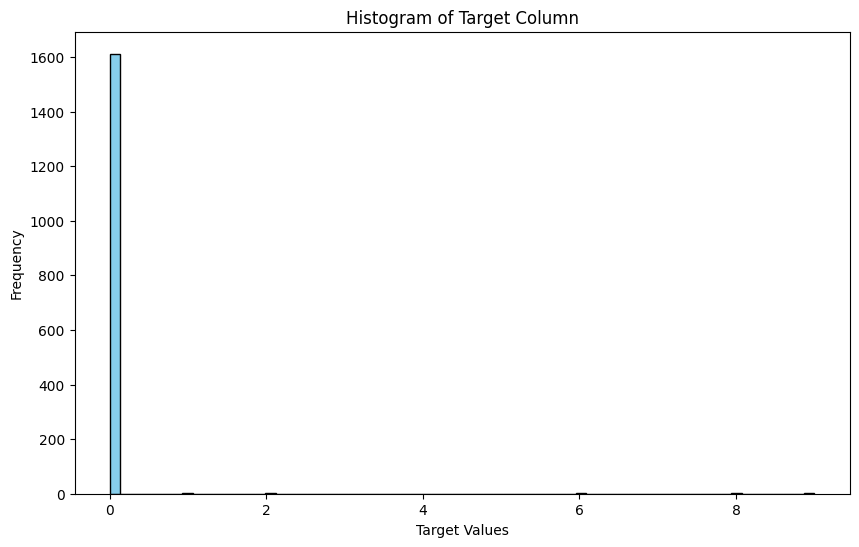

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

81

In [57]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

1

In [58]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
49,12209,0,0,0,0,1.000000,0.999999,0.999994,0.675998,True,True,True,True,False
299,35039,0,0,0,0,1.000000,1.000000,1.000000,0.503987,True,True,True,True,False
351,1123,0,0,0,0,1.000000,1.000000,0.999999,0.524274,True,True,True,True,False
377,48958,0,0,0,0,1.000000,1.000000,1.000000,0.730300,True,True,True,True,False
547,35456,0,0,0,0,0.999969,0.999999,0.999998,0.886350,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34573,36574,0,0,0,0,0.979893,0.999959,0.672549,0.700182,True,True,True,True,False
34596,7979,0,0,0,0,0.999999,0.999959,0.997214,0.872865,True,True,True,True,False
34886,2453,0,0,0,0,1.000000,1.000000,1.000000,0.598766,True,True,True,True,False
34953,44741,0,0,0,0,1.000000,1.000000,1.000000,0.884637,True,True,True,True,False


In [59]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,36844,1,1,0,1,1.000000,0.905026,1.000000,1.000000,True,False,True,False,False
1,38754,8,8,0,8,0.999946,0.973065,0.999998,1.000000,True,False,True,False,False
2,19121,7,0,7,7,0.983305,1.000000,1.000000,1.000000,False,True,True,True,True
3,42325,8,8,0,8,0.999969,0.967179,1.000000,1.000000,True,False,True,False,False
4,10851,4,0,4,4,0.997423,0.726803,0.447298,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,29746,8,8,0,8,0.999772,0.991589,0.999994,1.000000,True,False,True,False,False
9996,44388,5,0,5,5,0.389973,0.975449,0.872522,1.000000,False,True,True,True,True
9997,7014,0,0,0,0,0.999999,1.000000,0.974763,0.999992,True,True,True,True,False
9998,33868,9,9,0,9,0.999970,0.683973,0.999974,1.000000,True,False,True,False,False


In [60]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

29

In [61]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

7

In [62]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,29854,0,0,0,0,0.999999,1.000000,0.955096,0.708239,True,True,True,True,False
38,32016,0,0,0,0,1.000000,1.000000,0.999907,0.999187,True,True,True,True,False
44,15946,0,0,0,0,1.000000,1.000000,0.999972,0.986538,True,True,True,True,False
69,32401,0,0,0,0,1.000000,1.000000,1.000000,1.000000,True,True,True,True,False
70,45594,0,0,0,0,1.000000,0.999999,0.999375,1.000000,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9924,11958,0,0,0,0,1.000000,1.000000,1.000000,0.999951,True,True,True,True,False
9951,24388,9,1,6,6,0.633020,0.999961,0.873177,0.994132,False,False,False,True,False
9954,8296,0,0,0,0,1.000000,0.999999,0.995328,0.999424,True,True,True,True,False
9956,7444,0,0,0,0,0.999999,0.999996,0.999349,0.983768,True,True,True,True,False


In [63]:
df_results_v[(df_results_v['Target']==0)&(df_results_v['Match_T']!=True)&(df_results_v['Decision']==True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1109,11487,0,0,2,2,1.000000,0.750901,0.529348,0.999998,True,False,False,True,False
1298,21204,0,0,6,8,0.693013,0.990289,0.370330,0.986634,True,False,False,True,False
3373,39477,0,0,2,2,0.923454,0.977274,0.996545,1.000000,True,False,False,True,False
4939,14413,0,0,7,7,0.999998,0.624700,0.856848,1.000000,True,False,False,True,False
6125,24792,0,0,7,7,0.985811,0.821925,0.504377,0.999987,True,False,False,True,False
6940,31023,0,0,3,0,0.999871,0.720137,0.984000,0.999981,True,False,True,True,False
7368,35690,0,8,4,4,0.958972,0.994495,0.737922,0.999942,False,False,False,True,False
7816,33414,0,0,2,2,0.999669,0.999999,0.999790,1.000000,True,False,False,True,False
8292,22521,0,0,6,7,0.895434,0.618628,0.337492,0.998505,True,False,False,True,False
8314,38628,0,0,6,6,0.999586,0.477354,0.579864,1.000000,True,False,False,True,False


In [64]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

0    473
8     18
6      8
3      6
1      6
2      4
9      4
7      2
4      1
Name: Target, dtype: int64

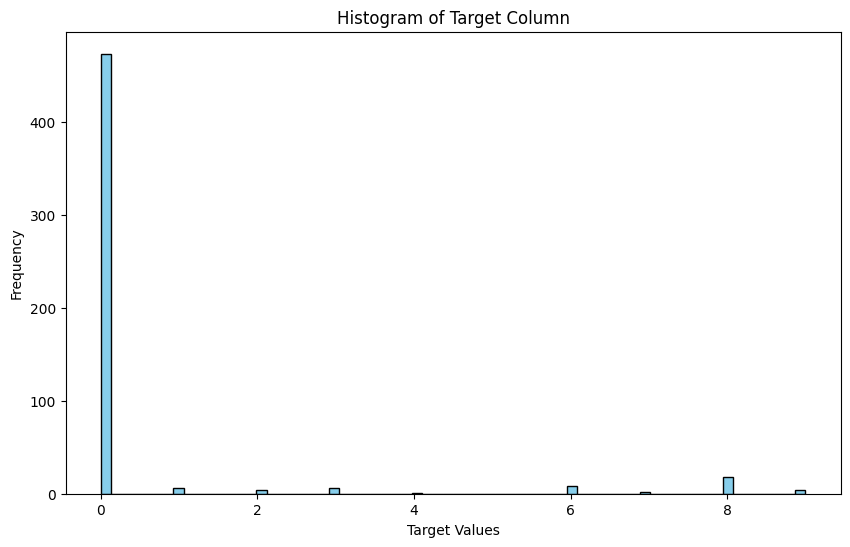

In [65]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [66]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
84,41274,0,0,0,7,0.974390,0.717194,0.412365,1.000000,True,True,False,True,False
230,33030,2,8,0,8,0.624430,0.962279,0.986022,0.998130,False,False,False,False,True
366,15097,0,0,0,0,0.998444,0.784972,0.999887,0.998910,True,True,True,True,False
435,3093,8,8,2,8,0.980623,0.471049,0.678292,0.999924,True,False,True,True,False
472,28323,8,8,5,8,0.999999,0.517228,0.570476,0.999411,True,False,True,True,False
804,15650,6,1,6,6,0.785444,0.996611,0.913605,0.947835,False,True,True,False,True
976,9226,8,8,3,3,0.994512,0.536862,0.786195,0.978774,True,False,False,True,False
1024,14986,3,9,3,9,0.601209,0.928616,0.598391,0.999939,False,True,False,False,True
1109,11487,0,0,2,2,1.000000,0.750901,0.529348,0.999998,True,False,False,True,False
1262,32869,6,8,6,6,0.720628,0.999044,0.994345,0.794506,False,True,True,False,True


In [67]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,29854,0,0,0,0,0.999999,1.000000,0.955096,0.708239,True,True,True,True,False
38,32016,0,0,0,0,1.000000,1.000000,0.999907,0.999187,True,True,True,True,False
44,15946,0,0,0,0,1.000000,1.000000,0.999972,0.986538,True,True,True,True,False
69,32401,0,0,0,0,1.000000,1.000000,1.000000,1.000000,True,True,True,True,False
70,45594,0,0,0,0,1.000000,0.999999,0.999375,1.000000,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9924,11958,0,0,0,0,1.000000,1.000000,1.000000,0.999951,True,True,True,True,False
9951,24388,9,1,6,6,0.633020,0.999961,0.873177,0.994132,False,False,False,True,False
9954,8296,0,0,0,0,1.000000,0.999999,0.995328,0.999424,True,True,True,True,False
9956,7444,0,0,0,0,0.999999,0.999996,0.999349,0.983768,True,True,True,True,False


In [68]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [69]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [70]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.0734389190141993, 0.9912857142857143, 12421, 22579)

In [71]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.4714869383793324, 0.923, 3612, 6388)

In [72]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [73]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.04495140838415495,
 0.9855142857142857,
 0.9855397630244737,
 0.9854808037777676,
 0.9854849549545686)

In [74]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.24949240554347635,
 0.9241,
 0.9240804858922826,
 0.9242998015581424,
 0.9240287334546669)

In [75]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.04496587559431791,
 0.9854571428571428,
 0.9854940920859192,
 0.9854288856896666,
 0.9854372699398593)